# Práctica 2 — Análisis Exploratorio de Datos

En este notebook realizarás un **análisis exploratorio de datos (EDA)** sobre un
dataset de 240 estrellas clasificadas en 6 tipos.

**Dataset:** [Stars Dataset — Kaggle](https://www.kaggle.com/datasets/waqi786/stars-dataset)

## Instrucciones generales
- Cada sección tiene celdas marcadas con `# tu código aquí` — ahí debes escribir tu solución.
- Lee las instrucciones en cada celda de markdown **antes** de escribir el código.
- Consulta los enlaces a la documentación oficial para entender los parámetros de cada función.
- Ejecuta el notebook completo **sin errores** antes de hacer commit (`Kernel → Restart & Run All`).

## Contenido
1. [Importar librerías](#1.-Importar-librerías)
2. [Cargar los datos](#2.-Cargar-los-datos)
3. [Exploración inicial](#3.-Exploración-inicial)
4. [Distribución por tipo de estrella](#4.-Distribución-por-tipo-de-estrella)
5. [Temperatura por tipo](#5.-Temperatura-por-tipo-de-estrella)
6. [Luminosidad vs Temperatura](#6.-Luminosidad-vs-Temperatura)
7. [Estadísticas con NumPy](#7.-Estadísticas-con-NumPy)
8. [Diagrama Hertzsprung-Russell](#8.-Diagrama-Hertzsprung-Russell)

---
## Configuración del ambiente

Este proyecto usa **Poetry** para gestionar las dependencias. Antes de abrir el notebook
ejecuta estos comandos **desde la carpeta `practica2_analisis_datos/`**:

```bash
poetry install
poetry run jupyter notebook
```

---
## 1. Importar librerías

Importa las cuatro librerías con sus **alias convencionales**.
Estos alias son estándares en la comunidad — siempre se usan así:

| Librería | Alias | ¿Para qué sirve? | Documentación |
|---|---|---|---|
| `numpy` | `np` | Operaciones matemáticas vectorizadas sobre arrays | [numpy.org/doc/stable](https://numpy.org/doc/stable/user/whatisnumpy.html) |
| `pandas` | `pd` | Análisis y manipulación de datos tabulares (DataFrames) | [pandas.pydata.org/docs](https://pandas.pydata.org/docs/getting_started/index.html) |
| `matplotlib.pyplot` | `plt` | Visualización de datos (gráficas de bajo nivel) | [matplotlib.org/tutorials](https://matplotlib.org/stable/tutorials/index.html) |
| `seaborn` | `sns` | Visualización estadística de alto nivel (sobre matplotlib) | [seaborn.pydata.org/tutorial](https://seaborn.pydata.org/tutorial.html) |

**Sintaxis:** `import librería as alias`

In [1]:
# Importa las cuatro librerías con sus alias convencionales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns




print(f'numpy   {np.__version__}')
print(f'pandas  {pd.__version__}')
print(f'seaborn {sns.__version__}')

numpy   2.4.4
pandas  3.0.2
seaborn 0.13.2


---
## 2. Cargar los datos

Usa [`pd.read_csv()`](https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html)
para leer el archivo CSV y cargarlo en un **DataFrame** de pandas.

- Revisa la documentación: ¿qué parámetro recibe `read_csv`? ¿qué devuelve?
- El archivo se encuentra en `'../data/star_dataset.csv'` (relativo a la carpeta `notebooks/`)
- Guarda el resultado en una variable llamada `stars`
- Después usa [`.head()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.head.html)
  para mostrar las primeras 5 filas

In [2]:
# Carga el archivo CSV con pd.read_csv() y guárdalo en 'stars'

stars = pd.read_csv("../practica2_analisis_datos/star_dataset.csv")

# Muestra las primeras 5 filas del DataFrame
print(stars.head(5))


             Name  Distance (ly)  Luminosity (L/Lo)  Radius (R/Ro)  \
0          Altair      16.594171           9.979192       1.632650   
1           Deneb    2600.490723      196002.627856     202.970526   
2  Barnard's Star       6.052616           4.893716       0.222711   
3         Polaris     322.601002        2196.241934      37.546813   
4  Barnard's Star       5.902392          -1.496486       0.192359   

   Temperature (K) Spectral Class  
0      7509.294247            A7V  
1      8503.284796           A2Ia  
2      3165.959639           M4Ve  
3      6048.326915           F7Ib  
4      3130.602069           M4Ve  


---
## 3. Exploración inicial

Antes de analizar datos siempre hay que entender qué tenemos.

**Celda 3a** — Imprime la información básica del DataFrame:
1. **Dimensiones** con [`.shape`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.shape.html)
   — devuelve una tupla `(filas, columnas)`
2. **Nombres de columnas** con [`.columns.tolist()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.columns.html)
3. **Tipos de datos** con [`.dtypes`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.dtypes.html)
   — indica si cada columna es `int64`, `float64` o `object` (texto)

**Celda 3b** — Obtén estadísticas descriptivas con
[`.describe()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.describe.html).
Fíjate en la media, desviación estándar, mínimo y máximo de cada columna numérica.

**Celda 3c** — Verifica si hay valores nulos con
[`.isnull()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.isnull.html)
seguido de `.sum()`. En un dataset limpio todos los valores deben ser 0.

In [3]:
# Imprime: dimensiones, nombres de columnas y tipos de datos
print("Dimensiones:")
print(stars.shape)
print("\nNombres de columnas:")
print(stars.columns.tolist())
print("\nTipos de datos:")
print(stars.dtypes)

Dimensiones:
(1000, 6)

Nombres de columnas:
['Name', 'Distance (ly)', 'Luminosity (L/Lo)', 'Radius (R/Ro)', 'Temperature (K)', 'Spectral Class']

Tipos de datos:
Name                     str
Distance (ly)        float64
Luminosity (L/Lo)    float64
Radius (R/Ro)        float64
Temperature (K)      float64
Spectral Class           str
dtype: object


In [4]:
# Obtén el resumen estadístico de las columnas numéricas
print(stars.describe().loc[['mean', 'std', 'min', 'max']])


      Distance (ly)  Luminosity (L/Lo)  Radius (R/Ro)  Temperature (K)
mean     295.505327       19644.909442      86.960696      9983.486779
std      541.478403       42223.595017     213.850005      7906.973529
min        3.877798          -4.993141       0.068087      2750.183163
max     2600.490723      196004.854081     887.097936     28044.279272


In [5]:
# Cuenta los valores nulos por columna
print(stars.isnull().sum())


Name                 0
Distance (ly)        0
Luminosity (L/Lo)    0
Radius (R/Ro)        0
Temperature (K)      0
Spectral Class       0
dtype: int64


---
## 4. Distribución por tipo de estrella

**Celda 4a** — Usa
[`.value_counts()`](https://pandas.pydata.org/docs/reference/api/pandas.Series.value_counts.html)
sobre la columna `'Spectral Class'` para contar cuántas estrellas hay de cada tipo.
Guarda el resultado en una variable llamada `conteo`.

> Pista: accede a una columna del DataFrame con `df['nombre_columna']`, que devuelve una **Serie**.
> `.value_counts()` es un método de Series.

**Celda 4b** — Crea una **gráfica de barras** de `conteo`:
1. La línea `plt.figure(figsize=(8, 4))` ya está incluida — no la borres
2. Llama [`.plot(kind='bar')`](https://pandas.pydata.org/docs/reference/api/pandas.Series.plot.html)
   sobre `conteo`, usando `color='steelblue'` y `edgecolor='black'`
3. Agrega título con `plt.title(...)`, etiquetas con `plt.xlabel(...)` y `plt.ylabel(...)`
4. Rota las etiquetas del eje X: `plt.xticks(rotation=30, ha='right')`

In [6]:
# Cuenta las estrellas por tipo y guarda el resultado en 'conteo'
conteo = stars['Spectral Class'].value_counts()


print(conteo)

Spectral Class
A7V         74
A1V         73
A9II        48
B1III       45
M3.5V       45
M2Iab       44
G8III       39
M4Ve        38
A0V         38
K1.5III     38
B2III       37
M7IIIe      37
B0Ia        36
G2V         36
F7Ib        35
B1III-IV    32
A3V         31
B0.5IV      30
F5IV-V      30
B6Vep       29
M2.1V       27
B7V         26
M1.5Iab     26
A2Ia        25
K1V         24
M6V         22
K5III       18
B8Ia        17
Name: count, dtype: int64


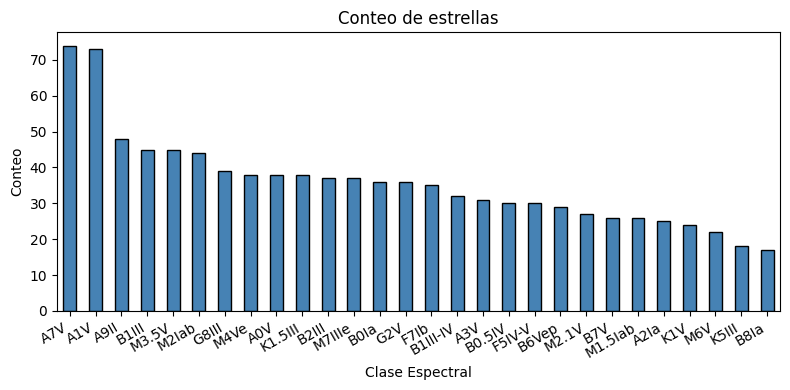

In [7]:
plt.figure(figsize=(8, 4))


# Crea la gráfica de barras con conteo.plot(kind='bar', color=..., edgecolor=...)
conteo.plot(kind='bar',color='steelblue', edgecolor='black')

# Agrega título y etiquetas de ejes
plt.title("Conteo de estrellas")
plt.xlabel("Clase Espectral")
plt.ylabel("Conteo")


plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

---
## 5. Temperatura por tipo de estrella

En esta sección calcularás la temperatura media de dos formas distintas para comparar.

**Celda 5a — Ciclo `for` (enfoque manual):**

Primero filtra el DataFrame para obtener solo las estrellas de tipo `'A7V'`:
```python
filtrado = stars[stars['Spectral Class'] == tipo_objetivo]
```
Luego recorre la columna `'Temperature (K)'` del DataFrame filtrado con un `for`,
acumula la `suma` y el `conteo` (`n`), y calcula la media como `suma / n`.

Consulta [cómo filtrar un DataFrame por valor](https://pandas.pydata.org/docs/getting_started/intro_tutorials/03_subset_data.html)
si necesitas orientación sobre la sintaxis de filtrado.

**Celda 5b — Pandas `.groupby()` (enfoque vectorizado):**

Usa [`.groupby()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.groupby.html)
para calcular la media de **todas las clases a la vez** en una sola línea:
```python
df.groupby('columna_categorica')['columna_numerica'].mean()
```
Ordena de mayor a menor con `.sort_values(ascending=False)`. Guarda en `temp_por_tipo`.
Compara el resultado de `'A7V'` con el valor que obtuviste con el `for`.

**Celda 5c — Boxplot:**

Usa [`sns.boxplot()`](https://seaborn.pydata.org/generated/seaborn.boxplot.html) con
`data=stars`, `x='Spectral Class'`, `y='Temperature (K)'`, `order=orden`.

In [8]:
# ── Enfoque 1: ciclo for ──────────────────────────────────────────────────────
tipo_objetivo = 'A7V'

# Paso 1: filtra el DataFrame para obtener solo las estrellas de tipo_objetivo (clase espectral)
# filtrado = ...
# tu código aquí
filtrado = stars[stars['Spectral Class'] == tipo_objetivo]

# Paso 2: recorre filtrado['Temperature (K)'] con un for
# acumula la suma y el conteo (n)
suma = 0
n = 0
for t in filtrado['Temperature (K)']:
    suma = suma + t
    n = n+1

# Calcula la media y guárdala en media_manual
# media_manual = suma / n

media_manual = suma/n

print(f'Temperatura media (for loop) : {media_manual:,.1f} K')

Temperatura media (for loop) : 7,550.2 K


### Comparación: `for` vs. pandas

Con el ciclo `for` calculaste la media de **una sola clase espectral** en varias líneas.
Ahora verás cómo pandas obtiene la media de **todas las clases a la vez** en una sola línea.

Cuando termines la celda 5b, verifica que el resultado de `A7V`
coincida con el valor que obtuviste con el `for`.

In [9]:
# ── Enfoque 2: pandas groupby ─────────────────────────────────────────────────
# Calcula la temperatura promedio por tipo con groupby
# Ordena de mayor a menor y guarda en temp_por_tipo
temp_por_tipo = stars.groupby('Spectral Class')['Temperature (K)'].mean().sort_values(ascending=False)


print('Temperatura promedio por clase espectral (K):')
print(temp_por_tipo.round(1))
print()
# Imprime una línea de verificación comparando media_manual con el valor de groupby para 'A7V'
print(f'media manual para A7V: {media_manual:.1f}K\nmedia por groupby en A7V: {temp_por_tipo["A7V"].round(1)}K')

Temperatura promedio por clase espectral (K):
Spectral Class
B0.5IV      28001.2
B0Ia        27502.3
B1III-IV    25403.2
B1III       25001.1
B2III       22600.1
B6Vep       15003.6
B7V         12462.1
B8Ia        12092.3
A1V         10136.0
A0V          9607.5
A3V          8584.7
A2Ia         8516.8
A7V          7550.2
A9II         7349.2
F5IV-V       6520.4
F7Ib         6020.4
G2V          5798.0
K1V          5261.6
G8III        4939.7
K1.5III      4280.1
K5III        3923.6
M2Iab        3502.2
M1.5Iab      3499.1
M2.1V        3408.9
M4Ve         3136.1
M7IIIe       2914.5
M3.5V        2802.6
M6V          2795.2
Name: Temperature (K), dtype: float64

media manual para A7V: 7550.2K
media por groupby en A7V: 7550.2K


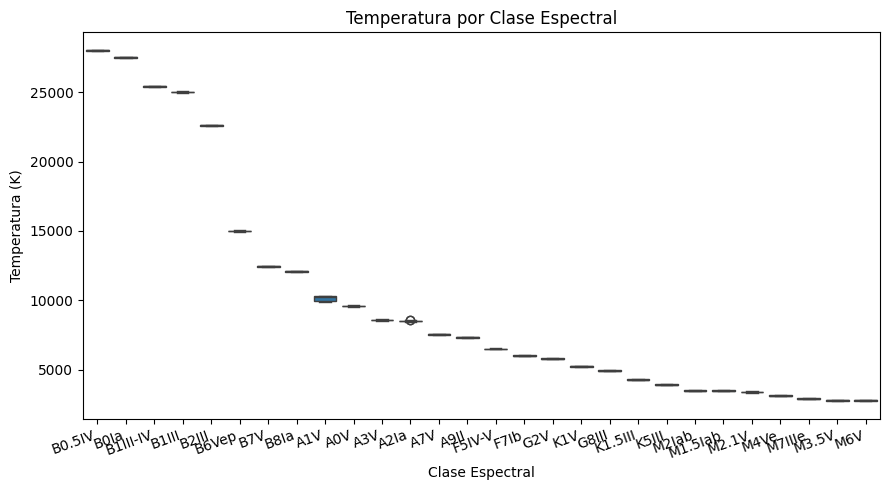

In [10]:
plt.figure(figsize=(9, 5))
orden = temp_por_tipo.index   # orden de mayor a menor temperatura

# Crea el boxplot con sns.boxplot(data=..., x=..., y=..., order=...)
sns.boxplot(data = stars, x = 'Spectral Class', y = 'Temperature (K)', order=orden)


# Agrega título y etiquetas de ejes
plt.title('Temperatura por Clase Espectral')
plt.xlabel('Clase Espectral')
plt.ylabel('Temperatura (K)')



plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

---
## 6. Luminosidad vs Temperatura

La luminosidad varía en muchos órdenes de magnitud (de 0.00008 a 849 420 L/Lo),
por eso necesitamos **escala logarítmica** en el eje Y.

Usa [`sns.scatterplot()`](https://seaborn.pydata.org/generated/seaborn.scatterplot.html)
con los siguientes parámetros (revisa la documentación para entender cada uno):
- `data=stars` — el DataFrame
- `x='Temperature (K)'` — temperatura en el eje X
- `y='Luminosity (L/Lo)'` — luminosidad en el eje Y
- `hue='Spectral Class'` — colorea los puntos según la clase espectral
- `style='Spectral Class'` — usa un marcador diferente por clase espectral
- `s=60` — tamaño de los puntos

Después de crear el plot, aplica escala logarítmica al eje Y con
[`plt.yscale('log')`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.yscale.html).

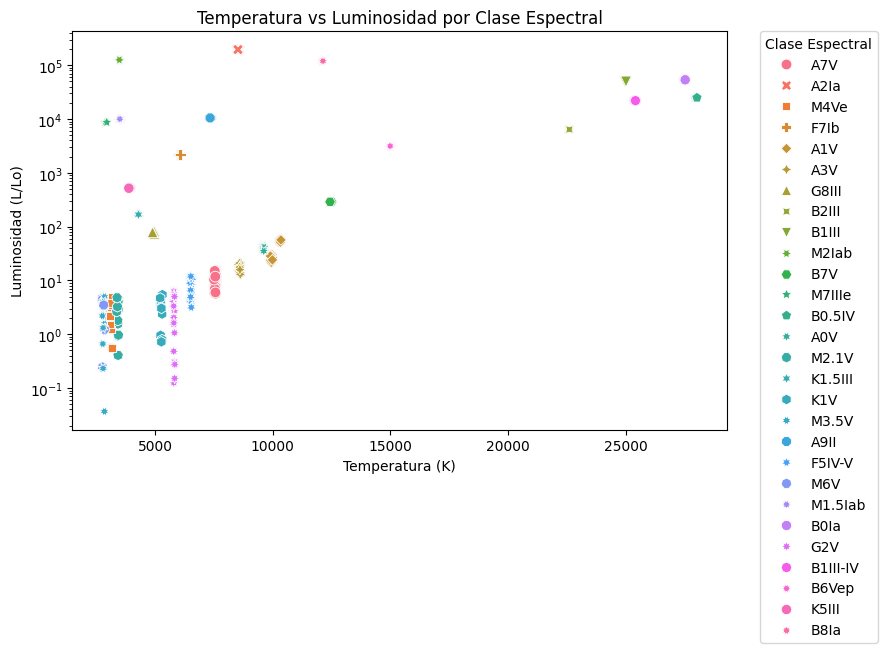

In [11]:
plt.figure(figsize=(9, 6))

# Crea el scatter plot con sns.scatterplot(...)
sns.scatterplot(data = stars, x='Temperature (K)', y='Luminosity (L/Lo)', hue='Spectral Class', style='Spectral Class', s=60)


# Aplica escala logarítmica al eje Y
plt.yscale('log')


# Agrega título, etiquetas de ejes y leyenda
plt.title('Temperatura vs Luminosidad por Clase Espectral')
plt.xlabel('Temperatura (K)')
plt.ylabel('Luminosidad (L/Lo)')
plt.legend(title='Clase Espectral', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)

# añadi bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0, ya que sino la leyenda cubre la gráfica


plt.tight_layout()
plt.show()

---
## 7. Estadísticas con NumPy

NumPy opera sobre **arrays completos** sin ciclos `for`. Por ejemplo,
`np.mean(arr)` calcula la media de todos los elementos de `arr` de una sola vez.

**Celda 7a** — Extrae los arrays con `.values` y calcula estadísticas:
- Extrae: `temperaturas = stars['Temperature (K)'].values`
- Extrae: `radios = stars['Radius (R/Ro)'].values`
- Verifica el tipo con `type(temperaturas)`
- Calcula usando estas funciones de [`numpy.statistics`](https://numpy.org/doc/stable/reference/routines.statistics.html):
  - [`np.mean(arr)`](https://numpy.org/doc/stable/reference/generated/numpy.mean.html) — media
  - [`np.median(arr)`](https://numpy.org/doc/stable/reference/generated/numpy.median.html) — mediana
  - [`np.std(arr)`](https://numpy.org/doc/stable/reference/generated/numpy.std.html) — desviación estándar
  - [`np.min(arr)`](https://numpy.org/doc/stable/reference/generated/numpy.amin.html) y [`np.max(arr)`](https://numpy.org/doc/stable/reference/generated/numpy.amax.html)

**Celda 7b** — Percentiles y conversión vectorizada:
- Usa [`np.percentile(arr, q)`](https://numpy.org/doc/stable/reference/generated/numpy.percentile.html)
  con `q=[25, 50, 75, 90]` para calcular los 4 percentiles de `radios` de una vez
- Convierte `temperaturas` de Kelvin a Celsius **sin usar ciclo `for`**:
  `celsius = temperaturas - 273.15` (operación vectorizada)

In [12]:
# Extrae los arrays NumPy con .values
temperaturas = stars['Temperature (K)'].values
radios = stars['Radius (R/Ro)'].values

# Imprime el tipo del array
print(f"Tipo del array: {type(temperaturas)}\n")


# Calcula e imprime: media, mediana, desv. estándar, mínima y máxima de temperaturas
print(f'Temperatura media: {np.mean(temperaturas).round(2)}')
print(f'Temperatura mediana: {np.median(temperaturas).round(2)}')
print(f'Desviación estándar: {np.std(temperaturas).round(2)}')
print(f'Temperatura mínima: {np.min(temperaturas).round(2)}')
print(f'Temperatura máxima: {np.max(temperaturas).round(2)}')

Tipo del array: <class 'numpy.ndarray'>

Temperatura media: 9983.49
Temperatura mediana: 7379.01
Desviación estándar: 7903.02
Temperatura mínima: 2750.18
Temperatura máxima: 28044.28


In [13]:
niveles = [25, 50, 75, 90]

# Calcula los percentiles del radio estelar con np.percentile(radios, niveles)
np.percentile(radios, niveles)


# Imprime cada percentil usando un ciclo for y zip(niveles, p)
for nivel, valor in zip(niveles, np.percentile(radios, niveles)):
    print(f"Percentil {nivel}: {valor:.2f}")


# Convierte temperaturas de Kelvin a Celsius de forma vectorizada (sin for)
celsius = temperaturas - 273.15


# Imprime las primeras 5 temperaturas en K y en C para comparar
# (usa np.round para redondear a 1 decimal)
print("Kelvin: ", np.round(temperaturas[:5], 1))
print("Celsius:", np.round(celsius[:5], 1))


Percentil 25: 1.66
Percentil 50: 5.85
Percentil 75: 33.72
Percentil 90: 369.93
Kelvin:  [7509.3 8503.3 3166.  6048.3 3130.6]
Celsius: [7236.1 8230.1 2892.8 5775.2 2857.5]


---
## 8. Diagrama Hertzsprung-Russell

El diagrama H-R es el gráfico más importante en astronomía estelar.
Relaciona temperatura con luminosidad y revela la estructura evolutiva de las estrellas.

Este diagrama tiene **dos particularidades** que debes implementar:
1. **Ambos ejes logarítmicos**: `plt.xscale('log')` y `plt.yscale('log')`
2. **Eje X invertido** (las más calientes a la izquierda): `plt.gca().invert_xaxis()`

**Estructura del código** (el inicio ya está dado, completa las partes marcadas):

```python
tipos   = stars['Spectral Class'].unique()
colores = sns.color_palette('tab10', len(tipos))   # paleta de colores
mapa    = dict(zip(tipos, colores))                # tipo -> color

for tipo, grupo in stars.groupby('Spectral Class'):
    plt.scatter(grupo['Temperature (K)'],
                grupo['Luminosity (L/Lo)'],
                label=tipo, color=mapa[tipo], s=40, alpha=0.8)
```

Parámetros de [`plt.scatter()`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html)
que debes entender: `x`, `y`, `label`, `color`, `s` (tamaño), `alpha` (transparencia).

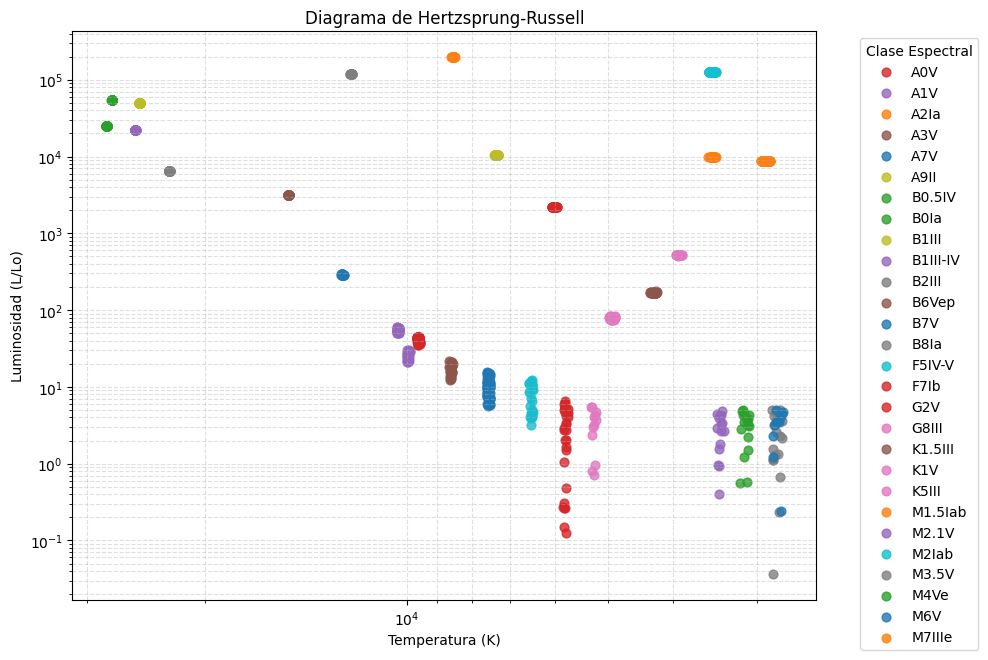

In [14]:
tipos   = stars['Spectral Class'].unique()
colores = sns.color_palette('tab10', len(tipos))
mapa    = dict(zip(tipos, colores))

plt.figure(figsize=(10, 7))

# Itera con stars.groupby('Spectral Class') y crea un plt.scatter() por cada tipo
for tipo, grupo in stars.groupby('Spectral Class'):
    plt.scatter(grupo['Temperature (K)'],
                grupo['Luminosity (L/Lo)'],
                label=tipo, color=mapa[tipo], s=40, alpha=0.8)


# Aplica escala logarítmica en ambos ejes (xscale y yscale)
plt.xscale('log')
plt.yscale('log')


# Invierte el eje X con plt.gca().invert_xaxis()
plt.gca().invert_xaxis()


# Agrega: título, etiquetas de ejes, leyenda y grid
plt.title('Diagrama de Hertzsprung-Russell')
plt.xlabel('Temperatura (K)')
plt.ylabel('Luminosidad (L/Lo)')
plt.legend(title='Clase Espectral', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, which='both', linestyle='--', alpha=0.4)


plt.tight_layout()
plt.show()